# Overview: Drone Contingency Management Model

## Why - Understanding drone safety in shared airspace

![](FBI-drone-collision.webp){fig-align="center"}


 - **Consider:**  Why can't drones and piloted aircraft fight fires at the same time?

- **Answer:** We don't yet know how to manage conflicts and drone-related hazards in the shared airspace with access restrictions

 - The goal of this model is to **better understand how to mitigate these hazards**

 <p class="small-text">PC: FBI/KTLA, ktla.com/news/california/wildfires/fbi-looking-for-pilot-of-drone-that-grounded-plane-battling-palisades-fire/</p>


## What are we trying to do?

Resilience models help us understand how well a system will mitigate hazardous scenarios. In this case, we want to:

1. Evaluate the ability of proximity to threat functionality to enable safe operations in drones

2. Identify backup/redundant battery storage requirements to mitigate battery depletion faults

3. Better understand how a given mission or Concept of Operations can affect resilience(s)

To do this, we adapt the base `airspacelib` library build with `fmdtools` to represent drone behavior, and its interactions with its environment in the relevant scenarios.

## Setup: Model Structure

:::: {.columns}

::: {.column width="50%"}

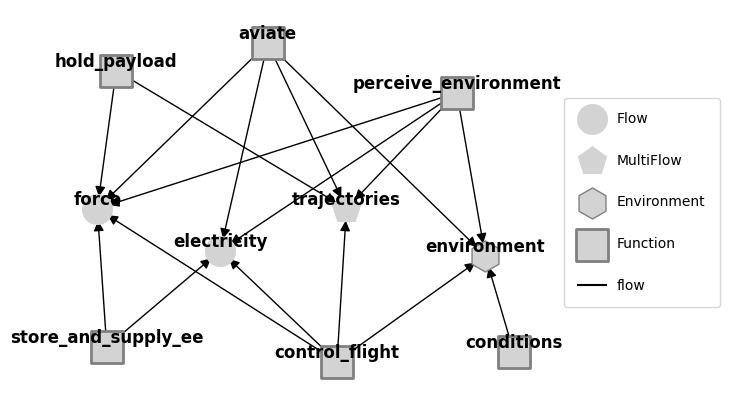

In [3]:
from fmdtools.define.architecture.function import FunctionArchitectureGraph
from model_aircraft import ContingencyAircraftArchitecture, pos
fg = FunctionArchitectureGraph(ContingencyAircraftArchitecture())
fg.set_edge_labels(title='')
fg.set_pos(**pos)
fig, ax = fg.draw(figsize=(6.5,5))



:::

::: {.column width="50%"}

- **aviate**: movement of the drone through the air
    - Alters true drone trajectory
- **control_flight**: path planning and control
    - Alters desired drone trajectory
- **store_and_supply_ee**: battery/energy storage
    - Provides electricity to other functions
- **perceive_environment**: Perception of drone location/environment
    - Determines perceived trajectory from true 
- **hold_payload**: Force balance/structure

- **conditions**: External update of environment
    - Determines external drone location(s)
:::
::::





## Setup: Environment and Mission

:::: {.columns}

::: {.column width="50%"}

![](outputs_demo_contingency/environment.svg)


:::

::: {.column width="50%"}

- Drone's mission is to fly from lower-left start point to upper-right end point

- Flies through area not designated "Restricted" (in gray)

- Can land in green "suitable" areas in emergencies

- Cannot land in Occupied (red) and Disallowed (blue) areas
:::
::::


## Setup: Path planning and reconfiguration 

:::: {.columns}

::: {.column width="50%"}  
![](outputs_demo_contingency/nominal_flightpath3d.gif)
:::

::: {.column width="50%"}
![](outputs_demo_contingency/nominal_flightpath.gif)
:::
::::

- Drone plans path to goal while avoiding restricted airspace and minimizing landing risks

- Drone at a constant height

- Re-plans when hazardous conditions are identified: **airspace intrusion** or **low battery**


## How resilient is the drone to airspace intrusion?

![bg right:50% width:400px vertical](outputs_demo_contingency/intrusion_without_proxthreat.gif)
![bg right:50% width:400px vertical](outputs_demo_contingency/intrusion_with_proxthreat.gif)

- Without proximity to threat functionality, drone may fly into errant intruding drone

- Proximity to threat functionality causes a pause in mission as well as mission re-planning

## Would the drone still be resilient to airspace intrusion in a different scenario? 

![50% width:400px vertical](outputs_demo_contingency/intrusion_middle_down.gif)
![50% width:400px vertical](outputs_demo_contingency/intrusion_middle_down_over.gif)

- If the intruder is easily avoidable, we can plan around it
- If not easily avoidable, this can cause issues
    - No logic for "running away"
    - May replan into restricted flight area

## How resilient is the drone to battery depletion?

:::: {.columns}

::: {.column width="50%"}  
![](outputs_demo_contingency/depletion_t20_traj.svg)
:::

::: {.column width="50%"}
![](outputs_demo_contingency/depletion_t20_line.gif)
:::
::::

- When SoC is below a threshold, flies to closest suitable location


## How resilient is the drone to battery depletion overall?


:::: {.columns}
::: {.column width="33%"}  
![](outputs_demo_contingency/depletion_25p_scens.gif){height=350}
:::
::: {.column width="33%"}
![](outputs_demo_contingency/depletion_18p_scens.gif){height=350}
:::
::: {.column width="33%"}
![](outputs_demo_contingency/depletion_0p_scens.gif){height=350}
:::
::::

- When there is some battery left, the drone is able to replan

- Otherwise, the drone may not make it to a suitable landing spot or may crash

## How resilient is the drone to battery depletion overall?


<style scoped>section { font-size: 20px; }</style>
|       Scenario SoC                  |   mission complete |   unsuitable site |   disallowed site |   occupied site |   damaged |   crashed |
|:------------------------|-------------------:|------------------:|------------------:|----------------:|----------:|----------:|
| 0% |                10 |                90 |                40 |              10 |       100 |       100 |
| 18% |                 10 |                40 |                20 |              20 |         0 |         0 |
| 25% |                 10 |                 0 |                 0 |               0 |         0 |         0 |

- Adequate mission recovery at 25% SoC - all suitable landings
- More unsuitable landings at 18% SoC (at 15% the drone lands immediately)
- At 0% the drone crashes

## Would the drone still be resilient in a different mission?

![](outputs_demo_contingency/25p_scens_all_disallowed.gif)

**No!**, consider the 25% depletion scenarios at right:

- Flying over disallowed area
- Statistics: 20% mission complete, 40% in disallowed locations

Effectiveness of drone safety features is **mission and scenario-dependent**

## Analysis Conclusions

Important Drone Features:
- Proximity to Threat functionality can improve drone resilience to flightplan intrusions

- Battery monitoring can also help improve drone resilience to battery faults

- Both of these require **in-flight environmental risk perception** and **risk-aware replanning** to be used effectively

But, **Execution Matters...**
- Need to have adequate battery redundancy to respond effectively--which may be different depending on the type of mission (are there bail-out points?)
- Re-planning to avoid approaching drones is more difficult than static ones


## Potential Future Work
- A variety of bug fixes and feature improvements
    - More robust logic for avoiding errant drones
    - More robust logic for battery depletion path planning
    - ...
- Can we use this to determine whether a drone is "safe enough" for a mission of interest
    - Mission: Start, end location and map
    - Is the battery adequate?
    - Can we bail out if another vehicle flies through?
- Evaluating other interesting hazardous scenarios
    - Wind, etc.

## Drone Resilience Library Conclusions
<style scoped>section { font-size: 25px; }</style>

1. Resilience models help us understand **dynamic** aspects of safety, such as...
    - **Dynamical system behaviors** (power draw, flight behavior, etc.) that key system functionality, performance, and safety is ultimately based on
    - **When/where a hazard occurs** in a dynamic mission/environmental context
    - **Dynamic resources (e.g., energy storage)** the system can leverage to mitigate those faults and their effectiveness

2. This Drone Library and resulting Contingency Management model was implemented in **fmdtools**, which provides straightforward interfaces for building, simulating, and analyzing resilience models in **Python**
    - Most analyses and visuals used fmdtools constructs (modeling classes, simulation and analysis methods) directly rather than writing custom code
    - Underlying methodology and code constructs **can be adapted to a range of applications** (autonomous vehicles, space, etc), not just drones
    - If you want to make something similar, **you don't have to start from scratch** (start with fmdtools!)